In [1]:
!nvidia-smi

Fri Apr 24 15:52:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   26C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
# Set multiple environment variables to fix GPU issues
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from keras_unet_collection import models
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [4]:
image_dir = "../dataset/image"
mask_dir  = "../dataset/mask"

images = os.listdir(image_dir)
masks= os.listdir(mask_dir)

print("Total images:", len(images))
print("Total Masks",len(masks))

Total images: 289
Total Masks 384


Image shape: (375, 1242, 3)


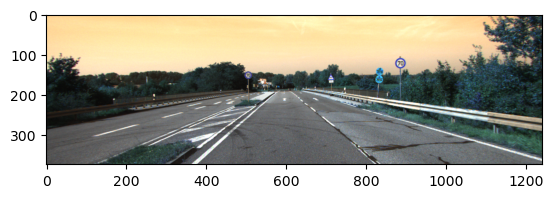

In [5]:
sample = images[10]

img = cv2.imread(os.path.join(image_dir, sample))
print("Image shape:", img.shape)

plt.imshow(img)

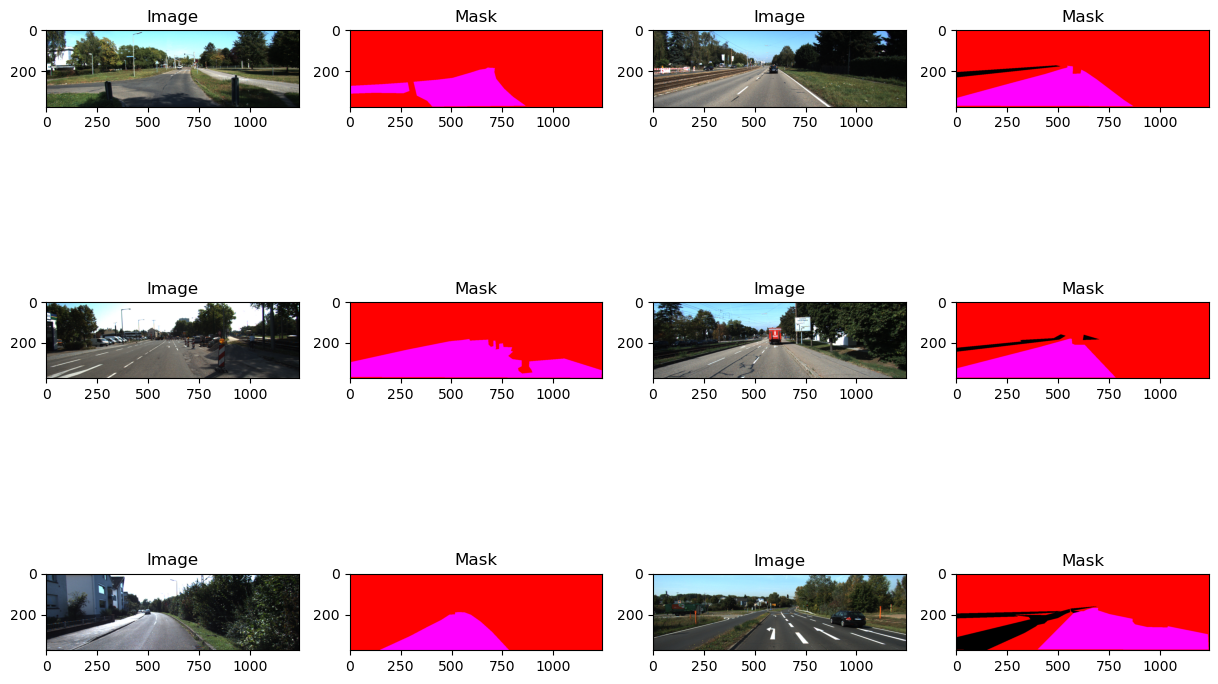

In [6]:
plt.figure(figsize=(15,10))

for i in range(6):

    sample = random.choice(images)

    prefix, rest = sample.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    img = cv2.imread(os.path.join(image_dir, sample))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, mask_name))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i*2+1)
    plt.imshow(img)
    plt.title("Image")

    plt.subplot(3,4,i*2+2)
    plt.imshow(mask)
    plt.title("Mask")

plt.show()

In [7]:
pixels = []

for img_name in images[:50]:
    img = cv2.imread(os.path.join(image_dir, img_name))
    pixels.append(img.mean())

print("Mean pixel intensity:", np.mean(pixels))

Mean pixel intensity: 94.87449656110216


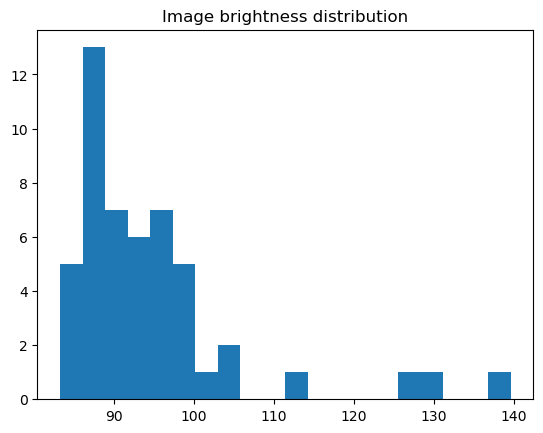

In [8]:
plt.hist(pixels, bins=20)
plt.title("Image brightness distribution")
plt.show()

In [9]:
for img_name in images[:5]:

    prefix, rest = img_name.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    print(img_name, "->", mask_name)

umm_000000.png -> umm_road_000000.png
umm_000001.png -> umm_road_000001.png
umm_000002.png -> umm_road_000002.png
umm_000004.png -> umm_road_000004.png
umm_000003.png -> umm_road_000003.png


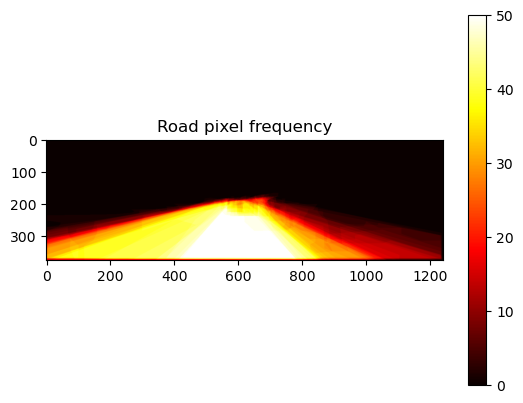

In [10]:
heatmap = np.zeros((375,1242))

for img_name in images[:50]:

    prefix, rest = img_name.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    mask = cv2.imread(os.path.join(mask_dir, mask_name))

    road = mask[:,:,0] == 255

    road = cv2.resize(road.astype(np.uint8), (1242,375))

    heatmap += road

plt.imshow(heatmap, cmap="hot")
plt.title("Road pixel frequency")
plt.colorbar()
plt.show()

In [11]:
def get_mask_name(img_name):
    prefix, rest = img_name.split("_",1)
    return f"{prefix}_road_{rest}"

In [12]:
IMG_SIZE = 256

def load_sample(img_name):

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, get_mask_name(img_name))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path)

    # road pixels
    road = mask[:,:,0] == 255
    mask = road.astype(np.float32)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    mask = np.expand_dims(mask,axis=-1)

    return img, mask

In [13]:
X=[]
Y=[]

for img_name in images:
    
    img,mask = load_sample(img_name)

    X.append(img)
    Y.append(mask)

X = np.array(X)/255.0
Y = np.array(Y).astype(np.float32)

print(X.shape,Y.shape)

(289, 256, 256, 3) (289, 256, 256, 1)


In [14]:
from sklearn.model_selection import train_test_split

X_train,X_val,Y_train,Y_val = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [15]:
model = models.unet_2d(
    (IMG_SIZE, IMG_SIZE, 3),
    filter_num=[64,128,256,512],
    n_labels=1,
    activation='ReLU',
    output_activation='Sigmoid'
)

I0000 00:00:1777045961.445248    4330 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [16]:
def dice_loss(y_true, y_pred):
    smooth = 1e-6

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - tf.reduce_mean(dice)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_loss,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(),
        tf.keras.metrics.MeanIoU(num_classes=2)
    ]
)

model.summary()

Model: "unet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0        │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0_activ… │ (None, 256, 256,  │          0 │ unet_down0_0[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1        │ (None, 256, 256,  │     36,928 │ unet_down0_0_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1_activ… │ (None, 256, 256,  │          0 │ unet_down0_1[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_encode_… │ (None, 128, 128,  │          0 │ unet_down0_1_act… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0   │ (None, 128, 128,  │     73,856 │ unet_down1_encod… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0_… │ (None, 128, 128,  │          0 │ unet_down1_conv_… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1   │ (None, 128, 128,  │    147,584 │ unet_down1_conv_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1_… │ (None, 128, 128,  │          0 │ unet_down1_conv_… │
│ (ReLU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_encode_… │ (None, 64, 64,    │          0 │ unet_down1_conv_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_0   │ (None, 64, 64,    │    295,168 │ unet_down2_encod… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_0_… │ (None, 64, 64,    │          0 │ unet_down2_conv_… │
│ (ReLU)              │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_1   │ (None, 64, 64,    │    590,080 │ unet_down2_conv_… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_1_… │ (None, 64, 64,    │          0 │ unet_down2_conv_… │
│ (ReLU)              │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down3_encode_… │ (None, 32, 32,    │          0 │ unet_down2_conv_… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down3_conv_0   │ (None, 32, 32,    │  1,180,160 │ unet_down3_encod

 Total params: 8,557,505 (32.64 MB)

 Trainable params: 8,557,505 (32.64 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=50,
    batch_size=4
)

Epoch 1/50


I0000 00:00:1777045970.046030    5142 service.cc:148] XLA service 0x5575dae113c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777045970.046079    5142 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-04-24 15:52:50.159907: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777045970.732484    5142 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-24 15:52:51.160058: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,64,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,3,256,256]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activati

57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - binary_accuracy: 0.2288 - loss: 0.7044 - mean_io_u: 0.4154

E0000 00:00:1777046009.859006    5142 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777046010.068583    5142 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777046010.852499    5142 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777046011.136053    5142 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 15:53:31.255481: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[3,512,32,32]{3,2,1,0}, u8[0]{0}) custom

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - binary_accuracy: 0.2313 - loss: 0.7037 - mean_io_u: 0.4158

2026-04-24 15:53:50.653638: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,64,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,3,256,256]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-04-24 15:53:50.904573: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,64,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,256,256]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivat

58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 870ms/step - binary_accuracy: 0.3760 - loss: 0.6584 - mean_io_u: 0.4418 - val_binary_accuracy: 0.7228 - val_loss: 0.4640 - val_mean_io_u: 0.5250
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - binary_accuracy: 0.8333 - loss: 0.3665 - mean_io_u: 0.4830 - val_binary_accuracy: 0.9089 - val_loss: 0.2640 - val_mean_io_u: 0.4378
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 244ms/step - binary_accuracy: 0.8897 - loss: 0.2815 - mean_io_u: 0.5390 - val_binary_accuracy: 0.9258 - val_loss: 0.2097 - val_mean_io_u: 0.4595
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 244ms/step - binary_accuracy: 0.9264 - loss: 0.2006 - mean_io_u: 0.4569 - val_binary_accuracy: 0.9299 - val_loss: 0.2675 - val_mean_io_u: 0.4132
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - binary_accuracy: 0.9132 - loss: 0.2223 - mean_io_u: 0.5145 - val_binary_accuracy: 0.9339 - val_loss: 0.1829 - val_mean_io_u: 0.7551
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 244ms/step - binary_accuracy: 0.93

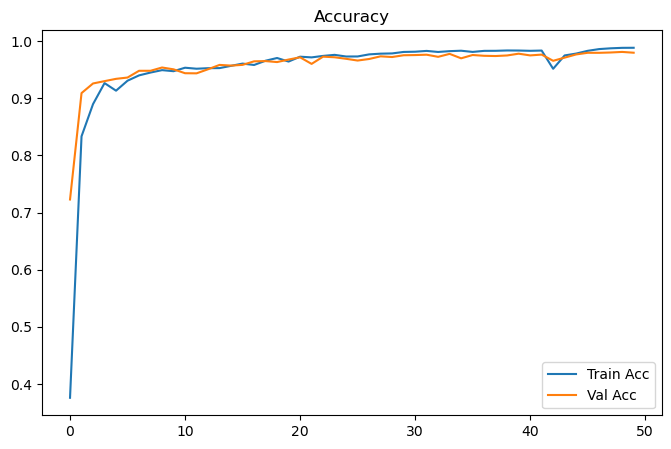

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history.history['binary_accuracy'], label="Train Acc")
plt.plot(history.history['val_binary_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.show()

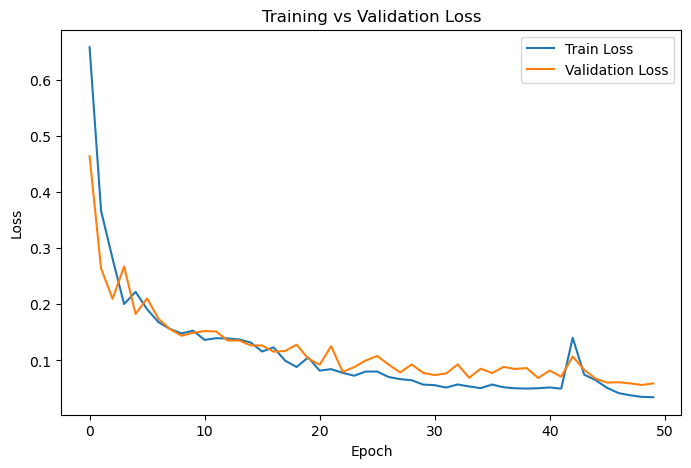

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

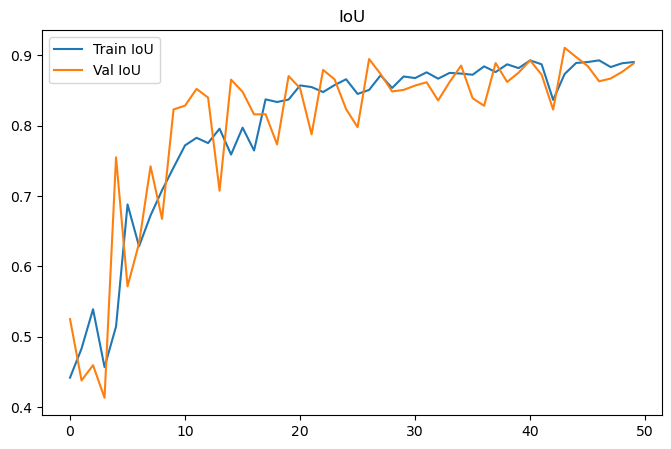

In [20]:
plt.figure(figsize=(8,5))
plt.plot(history.history['mean_io_u'], label="Train IoU")
plt.plot(history.history['val_mean_io_u'], label="Val IoU")
plt.legend()
plt.title("IoU")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


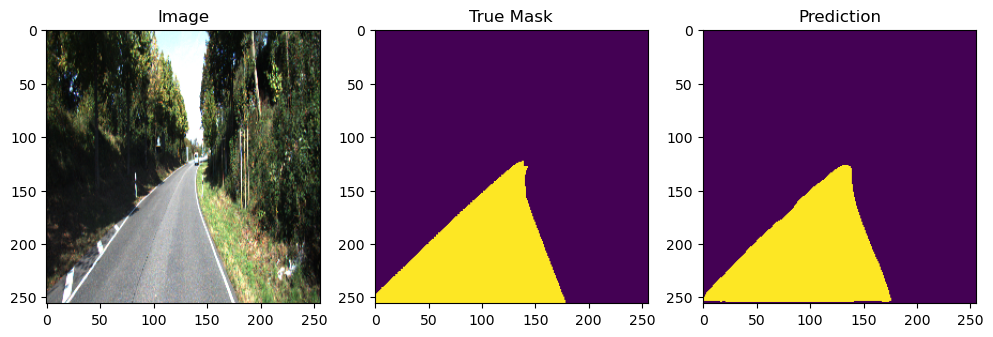

In [27]:
idx = 15
pred = model.predict(X_val[idx:idx+1])[0]
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(X_val[idx])
plt.title("Image")
plt.subplot(1,3,2)
plt.imshow(Y_val[idx].squeeze())
plt.title("True Mask")
plt.subplot(1,3,3)
plt.imshow(pred.squeeze() > 0.5)
plt.title("Prediction")
plt.show()

In [29]:
import tarfile

model.save("/home/sagemaker-user/code/Self-Driving_percerptron/models/model.keras")

with tarfile.open("../models/model.tar.gz", "w:gz") as tar:
    tar.add("/home/sagemaker-user/code/Self-Driving_percerptron/models/model.keras", arcname="model.keras")

In [ ]:
video_path = "/testing/solidYellowLeft.mp4"

cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

print(width, height, fps)

In [ ]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter("/kaggle/working/output.mp4",fourcc,fps,(width, height))

In [ ]:
IMG_SIZE = 256

def process_frame(frame):

    original = frame.copy()

    small = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    small = small / 255.0

    pred = model.predict(small[np.newaxis,...])[0]

    mask = pred.squeeze() > 0.5

    mask = cv2.resize(mask.astype(np.uint8), (width, height))

    overlay = original.copy()
    overlay[mask == 1] = [0,255,0]

    return overlay

In [ ]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    result = process_frame(frame)
    out.write(result)
cap.release()
out.release()